In [1]:
%matplotlib widget

# Piecewise inversion

In [2]:
import numpy as np
import pygimli as pg
import empymod as ep
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd
import sys
sys.path.insert(1, 'src')

from FDEM1D import FDEM1DModelling
from showStitched import showStitchedModels

/tmp/ipykernel_1629060/1164577800.py:7: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [8]:
# Load data

data_test = np.load('data/data_s0_c1_uc_sort.npy')

# number of measurement positions 
npos = len(data_test)

In [9]:
# Setting forward operator 

fop = FDEM1DModelling(nlay=2)

transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(10/1000,2000/1000)

fop.region(0).setTransModel(transThk)
fop.region(1).setTransModel(transSig)


In [10]:
# Perform inversion in each position

startModel = np.array([3, 0.5, 0.5])

model_est = []

for pos in range(npos):
    dat = data_test[pos]
    rel_err = np.ones_like(dat)*1e-3 
    inv = pg.Inversion(fop)
    model_est.append(inv.run(dataVals=dat, errorVals=rel_err, startModel=startModel, verbose=False, lam=0 ))

In [11]:
model_est = np.array(model_est)

<Axes: >

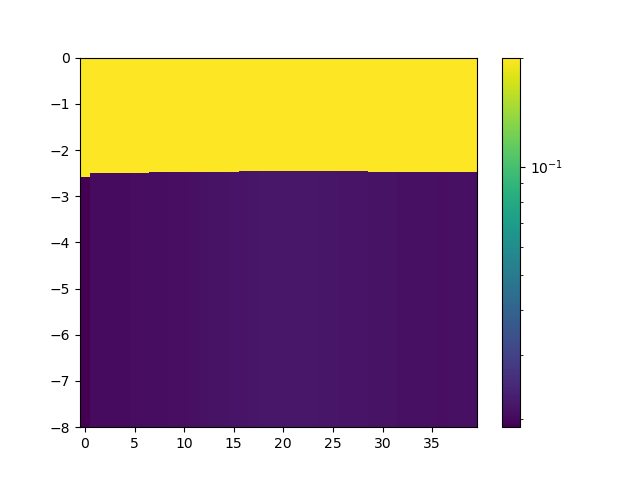

In [12]:
showStitchedModels(model_est, zMax=8)